<h1 align=center>A Practical Guide to Generative AI and LLMs for AI Engineers</h1>
This guide covers in simple words the essential building blocks and advanced concepts of modern Generative AI and LLM systems, from core fundamentals like tokens, embeddings, and prompt engineering to production-critical topics.

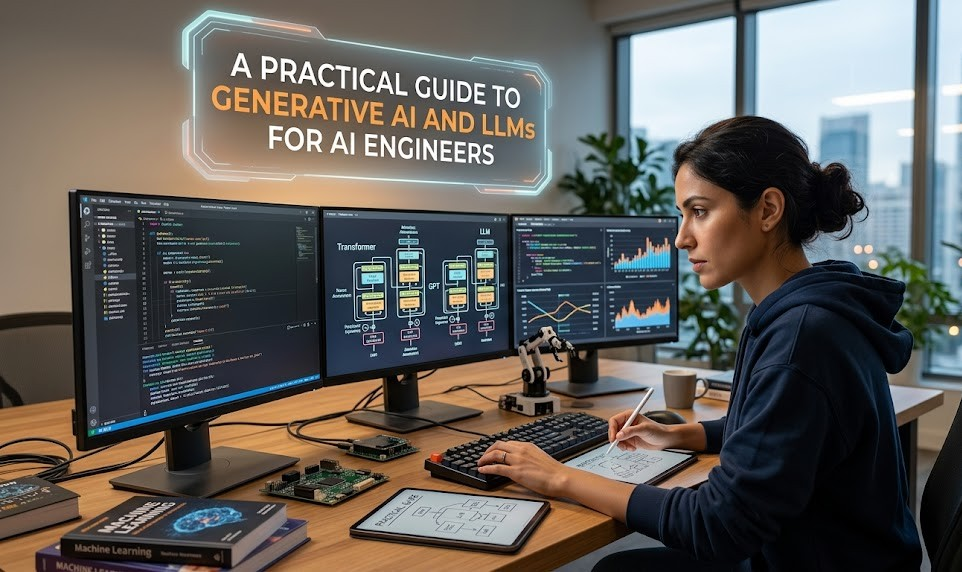

**Contents**
- Generative AI fundamentals
- LLMs
- Tokens
- Context windows
- Temperature
- Prompt engineering
- Embeddings
- RAG
- Vector databases
- Hallucinations
- Fine-tuning
- Agents
- Function calling
- Cost optimization
- Latency
- Evaluation
- Security
- Multimodal AI
- Open-source vs closed models
- Production architecture
- Monitoring
- AI Ethics & Responsible AI
- Data Engineering for AI
- Inference Optimization
- Orchestration Frameworks
- Future AI trends

---

## Introduction
Generative AI has transformed how software is built, automated, and scaled. Modern AI systems can write code, summarise documents, answer questions, generate images, automate workflows, and even act as autonomous agents.
For AI engineers, understanding the foundations behind Large Language Models (LLMs) is essential. Beyond prompt engineering, engineers must understand tokens, context windows, embeddings, inference costs, latency, retrieval systems, fine-tuning, and production deployment challenges.

---

## 1. What is Generative AI?
Generative AI refers to systems capable of producing new content, text, images, code, audio, and video by learning the statistical structure of training data. Unlike discriminative models that classify or predict, generative models learn a distribution and sample from it.

The field is built on two conceptual pillars: neural networks that approximate functions through learned parameters, and self-supervised learning that extracts signal from unlabeled data at scale. Both existed for decades, but the transformer architecture in 2017 unlocked a new regime of scale.

Major generative paradigms include Variational Autoencoders (VAEs) for latent-space learning, GANs for adversarial image synthesis, Diffusion models for high-quality media generation, and Autoregressive LLMs for language. Each has distinct training dynamics, failure modes, and production trade-offs.
- Traditional AI predicts labels or classifications.
- Generative AI creates entirely new outputs.

---

## 2. What are Large Language Models (LLMs)?
LLMs are autoregressive transformer models trained to predict the next token given a sequence of prior tokens. The transformer's self-attention mechanism allows every token to attend to every other token in context, a breakthrough over recurrent architectures that processed sequentially.
Modern LLMs go through three phases: pre-training on massive corpora using next-token prediction, instruction fine-tuning (SFT) to align behaviour with human intent, and RLHF / DPO to further shape responses using preference data.

2017 - Attention Is All You Need:
- Google publishes the transformer. Self-attention replaces recurrence.

2018 - BERT & GPT-1:
- Transfer learning arrives for NLP. Pre-train, then fine-tune.

2020 - GPT-3 (175B):
- Few-shot prompting emerges. Scale reveals in-context learning.

2022 - InstructGPT & ChatGPT:
- RLHF aligns models with human preferences at a consumer scale.

2023–26 - GPT-4, Claude, Gemini, Llama 3+:
- Multimodal, long-context, and open-weight models proliferate.

---

### 3. Understanding Tokens
Tokens are the chunks of text a model actually processes. They're not characters, not words, they're subword units produced by algorithms like Byte-Pair Encoding (BPE) or SentencePiece. A token is roughly 3–4 characters or ¾ of a word in English, but varies significantly by language and content type.
Example: "AI engineers build applications."

Possible tokens: ["AI", " engineers", " build", " applications", "."]

Tokens directly affect:
- Cost
- Speed
- Context limits
- Latency

Most LLM providers charge per token.

Example pricing model:
```bash
Operation     |    Cost
---------------------------------
Input Tokens  |    $0.005 per 1K tokens
Output Tokens |    $0.015 per 1K tokens
```

**Practical Example**

Suppose:
- Prompt = 3,000 tokens
- Output = 1,000 tokens
- Requests/day = 50,000

Total daily tokens: 200 million tokens/day

This can become extremely expensive without optimisation.

---

## 4. Context Windows
The context window is the amount of text an LLM can remember during inference. Think of it as the model's short-term memory.

A context window (or context length) is the maximum amount of information measured in tokens that a Large Language Model (LLM) can process and "remember" at one time during a single interaction.

Context windows have expanded dramatically: GPT-3 launched with 2,048 tokens; modern models operate at 128K–1M tokens. But larger isn't always better. The "lost in the middle" problem shows models reliably attend to the start and end of context but miss information buried in the middle.

**Practical Example**
Imagine uploading:
- 400-page PDF
- Entire GitHub repository
- Long meeting transcripts

Without sufficient context, the model forgets earlier information.

---

## 5. Temperature
Temperature controls randomness.

Lower temperature:
- More deterministic
- More factual
- Less creative

Higher temperature:
- More creative
- More varied
- More risky

```bash
Temperature  |   Behavior
-------------------------------
0.0 Highly   |   deterministic
0.2 Stable   |   production outputs
0.7 Balanced |   creativity
1.0+ Highly  |   creative/random
```
Use low temperature for:
- SQL generation
- Code generation
- RAG systems
- Data extraction

Use a higher temperature for:
- Marketing content
- Story writing
- Brainstorming

---

## 6. Prompt Engineering
Prompt engineering is the practice of designing inputs that reliably elicit desired outputs.

Good prompts include:
- Clear instructions
- Constraints
- Examples
- Desired output format

```bash
# Prompt engineering techniques

# Zero-Shot
# Few-Shot
# Chain-of-Thought
# Self-Consistency
# ReAct
# Tree of Thoughts
# Role Prompting
# System Prompts
# Structured Output
# Meta-Prompting
```
---

## 7. Embeddings
- Embeddings convert text into numerical vectors
- These vectors capture semantic meaning
- Similar meanings → Similar vectors

Example: "car" and "vehicle" produce nearby vectors.

**Embeddings power:**
- Semantic search
- Recommendation systems
- Retrieval-Augmented Generation (RAG)
- Similarity matching
- Clustering

---

## 8. Vector Databases
Vector databases store embeddings for efficient similarity search.

Vector databases are purpose-built to store, index, and query high-dimensional embedding vectors efficiently. Unlike relational databases that do exact lookups, vector DBs perform Approximate Nearest Neighbour (ANN) search, finding the most similar vectors quickly, trading a small accuracy loss for massive speed gains.

Popular vector DBs: Pinecone | Weaviate | Chroma | FAISS

Vector databases use specialised indexing methods, primarily Approximate Nearest Neighbour (ANN) algorithms, to speed up similarity searches among billions of high-dimensional vectors. Common types include HNSW (graph-based for speed), IVF (clustering-based for efficiency), and Product Quantisation (for compression), often tailored to balance speed, accuracy, and memory.

---

## 9. Retrieval-Augmented Generation (RAG)
RAG gives an LLM access to external knowledge sources instead of relying only on what was learned during training.

RAG combines:
- Search systems
- External knowledge
- LLM reasoning

Instead of relying only on model memory, the system retrieves relevant information first.

---

## 10. Hallucinations
Hallucination in AI means the LLM generates information that sounds correct but is actually false, made up, or unsupported.

Simple Example

User:
- "Who invented the iPhone in 2003?"

LLM hallucination:
- "John Smith invented the iPhone in 2003."

This sounds believable, but is false.

---

## 11. Fine-Tuning
Fine-tuning means training an already pre-trained AI model on your own specific data so it becomes better at a particular task or domain.

Unlike prompting:
- Prompting changes the input instructions
- Fine-tuning changes the model itself

After fine-tuning, the model naturally behaves the way you want without long prompts.

Simple Example

A general AI model:
- Knows many topics

After fine-tuning on medical data:
- Becomes much better at medical questions

Fine-tuning = customizing a pre-trained model by training it on specialized data.

---

## 12. Agents
An AI agent is a system where an LLM serves as a reasoning engine that can take actions, calling tools, searching the web, running code, updating state, and observe results, iterating until a goal is achieved. 

Agents break from the one-shot request-response model to enable multi-step autonomous workflows.
```bash
             Goal / Task
                  ↓
          LLM Planner (Reason)
                  ↓
Tool: Search    Tool: Code    Tool: API    Tool: Memory
                  ↓ Observation
           Update State & Re-plan
                  ↓ (loop until done)
              Final Output
```
Agent architectures include ReAct (Reason + Act interleaved), Plan-and-Execute (plan upfront, then dispatch), multi-agent systems (specialised agents collaborating), and hierarchical agents (orchestrator-worker patterns). Each trades latency for capability and reliability.

---

## 13. Function Calling
Function calling (or "tool use") allows models to output structured JSON that represents a function invocation rather than free-form text. Your code defines available tools with JSON schemas; the model decides when and how to call them. This bridges natural language and deterministic APIs.

---

## 14. AI System Costs
AI engineers must optimise:
- Token usage
- Latency
- GPU utilization
- Prompt sizes
- Retrieval quality

### Cost Optimisation Techniques
1. Prompt Compression
- Reduce unnecessary instructions

2. Caching
- Reuse previous responses

3. Smaller Models
- Use lightweight models where possible

4. Chunking
- Send only relevant documents

5. Hybrid Pipelines
- Use traditional ML before LLM calls

---

15. Latency
LLM speed has two parts:
```bash
| Term                         | Simple Meaning                             |
| ---------------------------- | ------------------------------------------ |
| TTFT (Time To First Token)   | How long the AI takes to start responding  |
| TPOT (Time Per Output Token) | How fast the AI continues generating words |
```
**Example**
You ask a question:
- TTFT = waiting before the first word appears
- TPOT = speed of the rest of the answer

**Streaming**
Streaming shows the answer word-by-word as it is generated instead of waiting for the full response.
Even if total generation time stays the same, streaming makes the AI feel much faster and more responsive.

---

## 16. Model Evaluation
Evaluations (evals) are tests used to measure how well an AI system performs.

Without evals:
- Changing prompts is mostly guessing
- Upgrading models is risky because quality may improve or get worse

Good evals help make AI systems reliable.

Simple Process
1. Create a golden dataset
- Real example questions and expected answers

2. Run tests whenever you:
- Change prompts
- Change models
- Update retrieval logic

3. Measure results over time
- Accuracy
- Relevance
- Hallucinations
- Latency

4. Continuously improve the system

**Why evals matter**

They help you:
- Detect regressions
- Compare models
- Improve quality safely
- Build trustworthy AI products

**Popular eval tools**
- LangChain's LangSmith
- Braintrust
- Confident AI

Evals = systematic testing to measure and improve AI system quality.
```bash
# Automated Evals (done by machines)
| Type                           | Simple Meaning                                                             |
| -------------------------------| -------------------------------------------------------------------------- |
| LLM-as-judge                   | Another LLM (like GPT-4) grades the answer quality.                        |
| Reference-based                | Compares output to a correct answer using metrics like ROUGE or BERTScore. |
| Task-specific (pass@k)         | Checks if the correct solution appears in top-k tries (common in coding).  |
| Factual accuracy via retrieval | Verifies answers using external sources (e.g., documents or databases).    |
```
```bash
# Human Evals (done by people)
| Type                  | Simple Meaning                                        |
| --------------------- | ----------------------------------------------------- |
| A/B preference tests  | Humans choose which of two answers is better.         |
| Expert review         | Domain experts check correctness and quality.         |
| Red-teaming           | Humans try to break the system or find safety issues. |
| User feedback signals | Real users rate satisfaction or engagement.           |
```
---

## 17. Security and AI Safety
LLM security is about protecting training data, model behaviour, and outputs from manipulation or leakage.
```bash
| Attack                  | Simple Meaning                                                          | How to Reduce It                                                        |
| ----------------------- | ----------------------------------------------------------------------- | ----------------------------------------------------------------------- |
| **Prompt Injection**    | Hidden instructions in input try to trick the model into ignoring rules | Clean/sanitize inputs, separate user data from system instructions      |
| **Jailbreaking**        | User tricks the model into bypassing safety rules                       | Use multiple safety filters and guardrails                              |
| **Data Poisoning**      | Bad or malicious data is added during training                          | Use trusted data sources and filter training data                       |
| **Model Inversion**     | Attacker tries to extract private training data from outputs            | Use privacy techniques (like differential privacy) and output filtering |
| **Supply Chain Attack** | Downloading compromised model weights or dependencies                   | Verify sources, checksums, and scan models before use                   |
| **PII Leakage**         | Model accidentally reveals personal sensitive data                      | Remove sensitive data from training and block it in outputs             |
```
- Attacks = ways to trick or exploit LLMs
- Mitigations = data cleaning, filtering, safety layers, and privacy protections

---

## 18. Multimodal AI
Multimodal models process and generate across more than one data type: text, images, audio, video, and code. Vision-language models (VLMs) like GPT-4o, Claude 3.5, and Gemini Ultra accept images alongside text, enabling document analysis, chart reading, and visual reasoning without separate pipelines.

---

## 19. Open-Source vs Closed Models
**Closed Models**

Examples:
- GPT
- Claude
- Gemini

Pros:
- Strong performance
- Managed infrastructure

Cons:
- Higher cost
- Limited customization

**Open-Source Models**

Examples:
- Llama
- Mistral
- DeepSeek

Pros:
- Full control
- Self-hosting
- Fine-tuning flexibility

Cons:
- Infrastructure complexity
- GPU requirements

Most teams start with closed APIs for speed, then migrate volume workloads to open-source as they scale. It's not either/or; it's a portfolio decision.

---

## 20. Production Architecture for AI Systems
Typical AI architecture:

**Frontend ↓ API Gateway ↓ Application Server ↓ Retrieval Layer ↓ LLM Provider ↓ Monitoring & Logging**

**Essential Production Components**
- Rate limiting
- Observability
- Prompt versioning
- Caching
- Retry systems
- Guardrails
- Analytics

---

## 21. Monitoring and Observability
**Monitor:**

- Token usage
- Failure rates
- Hallucinations
- User feedback
- Cost spikes
- Latency trends

**Observability Platforms**

LangSmith, Langfuse, Arize Phoenix, Helicone, and Weights & Biases Weave all provide LLM-native tracing with full prompt/response logging, cost attribution, and eval integration. Log everything in development and use sampling in production.

---

## 22. AI Ethics & Responsible AI
Ethics in AI engineering isn't a philosophical afterthought; it's a set of concrete design decisions. Bias in training data propagates to outputs. Opaque systems undermine user trust. Automated decisions at scale require accountability structures that traditional software rarely needed.

- **Bias auditing:** Test model outputs across demographic groups; measure disparate impact
- **Transparency:** Disclose when users interact with AI; provide reasoning trails
- **Consent:** Be explicit about data usage in training and fine-tuning
- **Human oversight:** Maintain meaningful human review for consequential decisions
- **Content safety:** Layer classifiers for harmful content, especially in open-ended systems
- **Accessibility:** Ensure AI features work for users with disabilities; don't assume modalities
- **Environmental impact:** Measure and report the energy cost of training and inference

---

## 23. Data Engineering for AI
For fine-tuning, RAG pipelines, and evaluation, data quality is the dominant variable. Garbage in, garbage out applies with particular force to LLMs, which can confidently learn and reproduce patterns from bad data.

Key data engineering concerns: data collection (sourcing diverse, high-quality examples), cleaning (deduplication, language filtering, PII removal), annotation (human labelling for preference data), format standardisation (JSONL, conversation formats), and versioning (tracking dataset provenance with tools like DVC or Hugging Face Datasets).

---

## 24. Inference Optimisation
When self-hosting models, inference optimisation determines whether your deployment is economically viable. The GPU is the bottleneck; every technique below is about using GPU compute and memory more efficiently.

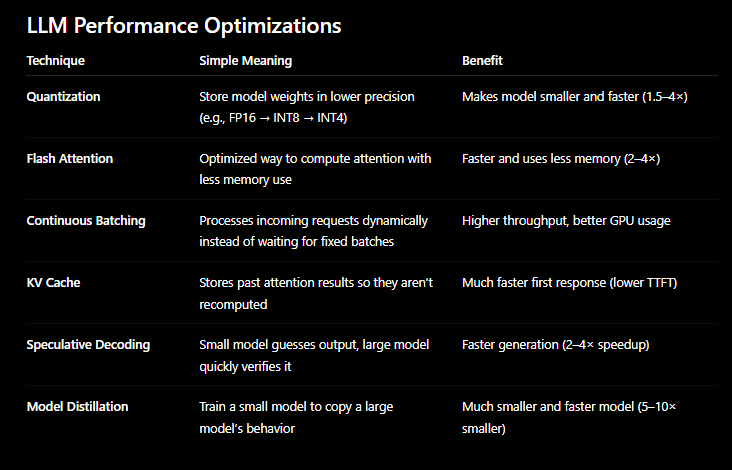

Inference servers like vLLM, TGI (Hugging Face), TensorRT-LLM (NVIDIA), and llama.cpp implements these optimisations. Choose based on your GPU type, model architecture, and throughput requirements.

---

## 25. Orchestration Frameworks
Orchestration frameworks handle the plumbing of LLM applications: chaining calls, managing memory, connecting tools, and coordinating agents. They raise the abstraction level from raw API calls to composable workflows.

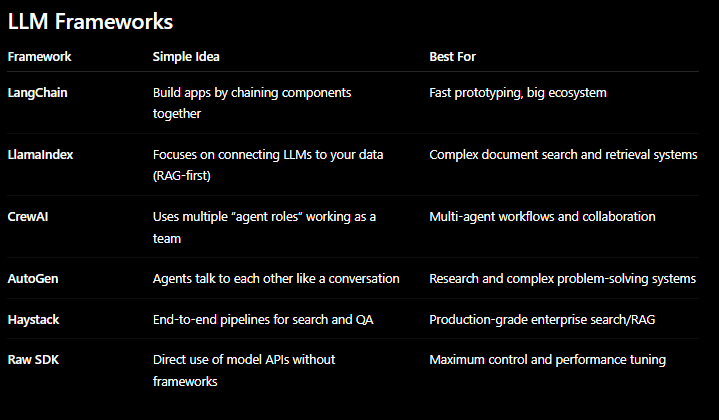

---

## 26. Future AI Trends
The AI field is moving faster than any previous technology wave. Frontier capabilities double roughly every 6–12 months. Engineers who understand the fundamentals will navigate each wave; those who only know the current tools will constantly scramble to catch up.

**Now - Agentic Workflows at Scale**
- Multi-agent systems handling real enterprise processes; long-horizon tasks with tool use becoming production reality.

**2026 - Reasoning Models Mainstream**
- Models like o3, DeepSeek-R2 that "think before they answer" become standard for complex problem-solving.

**2026–27 - Multimodal & Omnimodal**
- Native video understanding, real-time voice, and unified models across all modalities blur application boundaries.

**2027+ - AI Software Engineers**
- Fully autonomous coding agents that ship features, write tests, and respond to issues reshaping software development workflows.

**Horizon - Physical AI & Robotics**
Foundation models extending into robotics and the physical world via embodied AI, driven by vision-action models.

**AI engineering is evolving toward:**
- Autonomous agents
- Real-time reasoning
- Personalized AI
- Smaller efficient models
- AI-native software architectures

"The engineers who understand both software engineering and AI infrastructure will lead the next generation of applications."

"The best AI engineers of the next decade won't be those who know the most tools, they'll be the ones who understand the principles well enough to adapt to whatever comes next."